# MMC: run and compare SSN and direct MNA

1. **Setup:** load the helper functions.
2. **Settings:** choose the time step and prepare the programs.
3. **SSN:** run Matthias' original example and immediately display its plots.
4. **MNA:** run the example with `MMC_MNA` and immediately display its plots.
5. **Comparison:** overlay the results and display differences and error metrics.

## 1. Setup

In [1]:
import importlib
import sys
from pathlib import Path

candidates = [Path.cwd(), *Path.cwd().parents, Path('/home/ssc/HVDC/dpsim')]
REPO = next((p for p in candidates if
             (p / 'dpsim-models/src/EMT/EMT_Ph3_MMC_MNA.cpp').is_file()), None)
if REPO is None:
    raise FileNotFoundError('DPSim repository not found. Adjust the path in candidates.')
REPO = REPO.resolve()
notebook_directory = REPO / 'examples/Notebooks/Components'
if str(notebook_directory) not in sys.path:
    sys.path.insert(0, str(notebook_directory))
import EMT_MMC_MNA_Notebook as mmc_notebook
importlib.reload(mmc_notebook)

print(f'Repository: {REPO}')
print(f'Python: {sys.executable}')
print('Setup complete. Continue with the settings.')


Repository: /home/ssc/HVDC/dpsim
Python: /usr/bin/python
Setup complete. Continue with the settings.


## 2. Shared settings

Configure the experiment here. **Both models receive the same settings.**

| Setting | Meaning |
|---|---|
| `TIME_STEP = 20e-6` | 20 µs; change to `10e-6` for the finer run |
| `SIMULATION_TIME = 10.0` | Simulate 10 s; use e.g. `0.05` for a short check |
| `THETA = 0.5` | Trapezoidal integration, as in the previous comparison |
| `LOG_INTERVAL = 200e-6` | Save results every 200 µs: every tenth step at 20 µs |
| `REBUILD = True` | Update the existing build; unchanged files are not recompiled |

Each execution of this cell creates a **new experiment directory** under `outputs/mmc_mna/notebook_runs/`. After changing settings, run **both simulation cells again**. The comparison uses the runs belonging to this experiment.

Keep the simulation time at **10.0 s** to include all three power setpoint steps.


In [2]:
TIME_STEP = 20e-6
SIMULATION_TIME = 10.0
THETA = 0.5
LOG_INTERVAL = 200e-6
REBUILD = True

experiment = mmc_notebook.MMCExperiment(
    REPO,
    time_step=TIME_STEP,
    final_time=SIMULATION_TIME,
    theta=THETA,
    log_interval=LOG_INTERVAL,
)
experiment.prepare(rebuild=REBUILD)


Building examples is starting. Log: /home/ssc/HVDC/dpsim/outputs/mmc_mna/notebook_runs/20260928_103243_mmx4z6km/build.log


Building examples: completed in 0 min 01.3 s.


**Ready:** 10 s simulation time, 20 µs EMT step, theta 0.5; Logging every 10 steps (200 µs).

**Output directory:** `/home/ssc/HVDC/dpsim/outputs/mmc_mna/notebook_runs/20260928_103243_mmx4z6km`

Run the SSN cell next.

## 3. Run and plot the original SSN example

This cell runs **`EMT_SSN_MMC_Matlab_P2P_Results`**. 

The rectifier's initially negative active power follows the sign convention and is expected.


SSN MMC is starting. Log: /home/ssc/HVDC/dpsim/outputs/mmc_mna/notebook_runs/20260928_103243_mmx4z6km/ssn_wwjbradl/run.log


SSN MMC: completed in 3 min 45.6 s.
CSV checked: 50,001 samples. Creating individual plots …


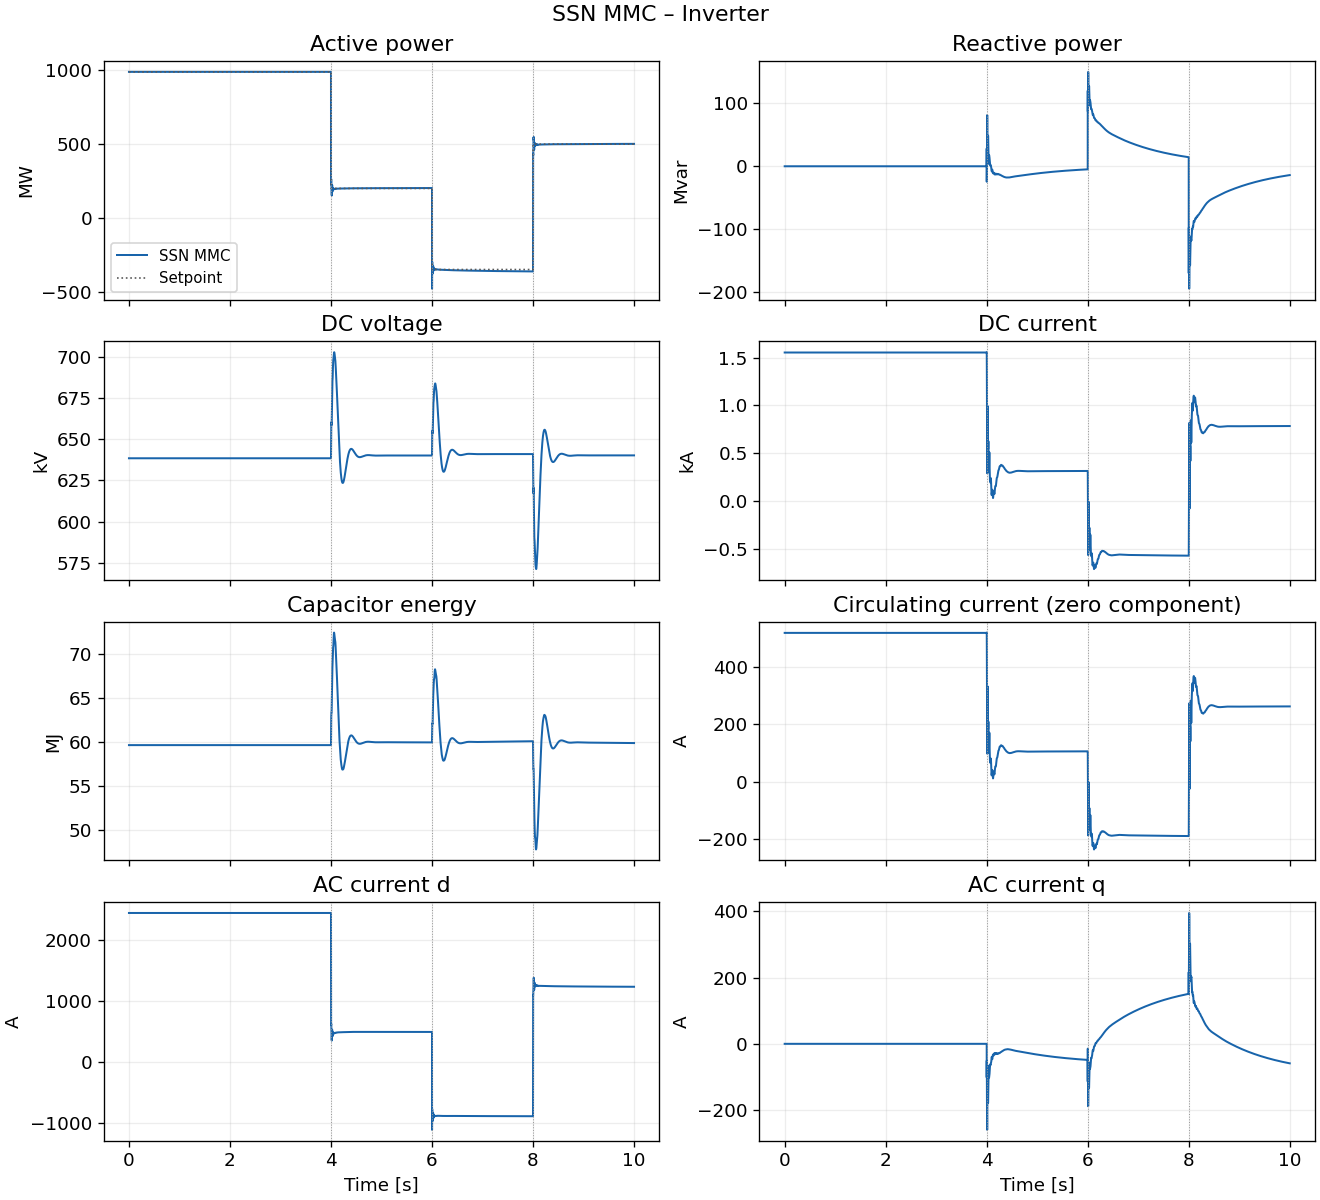

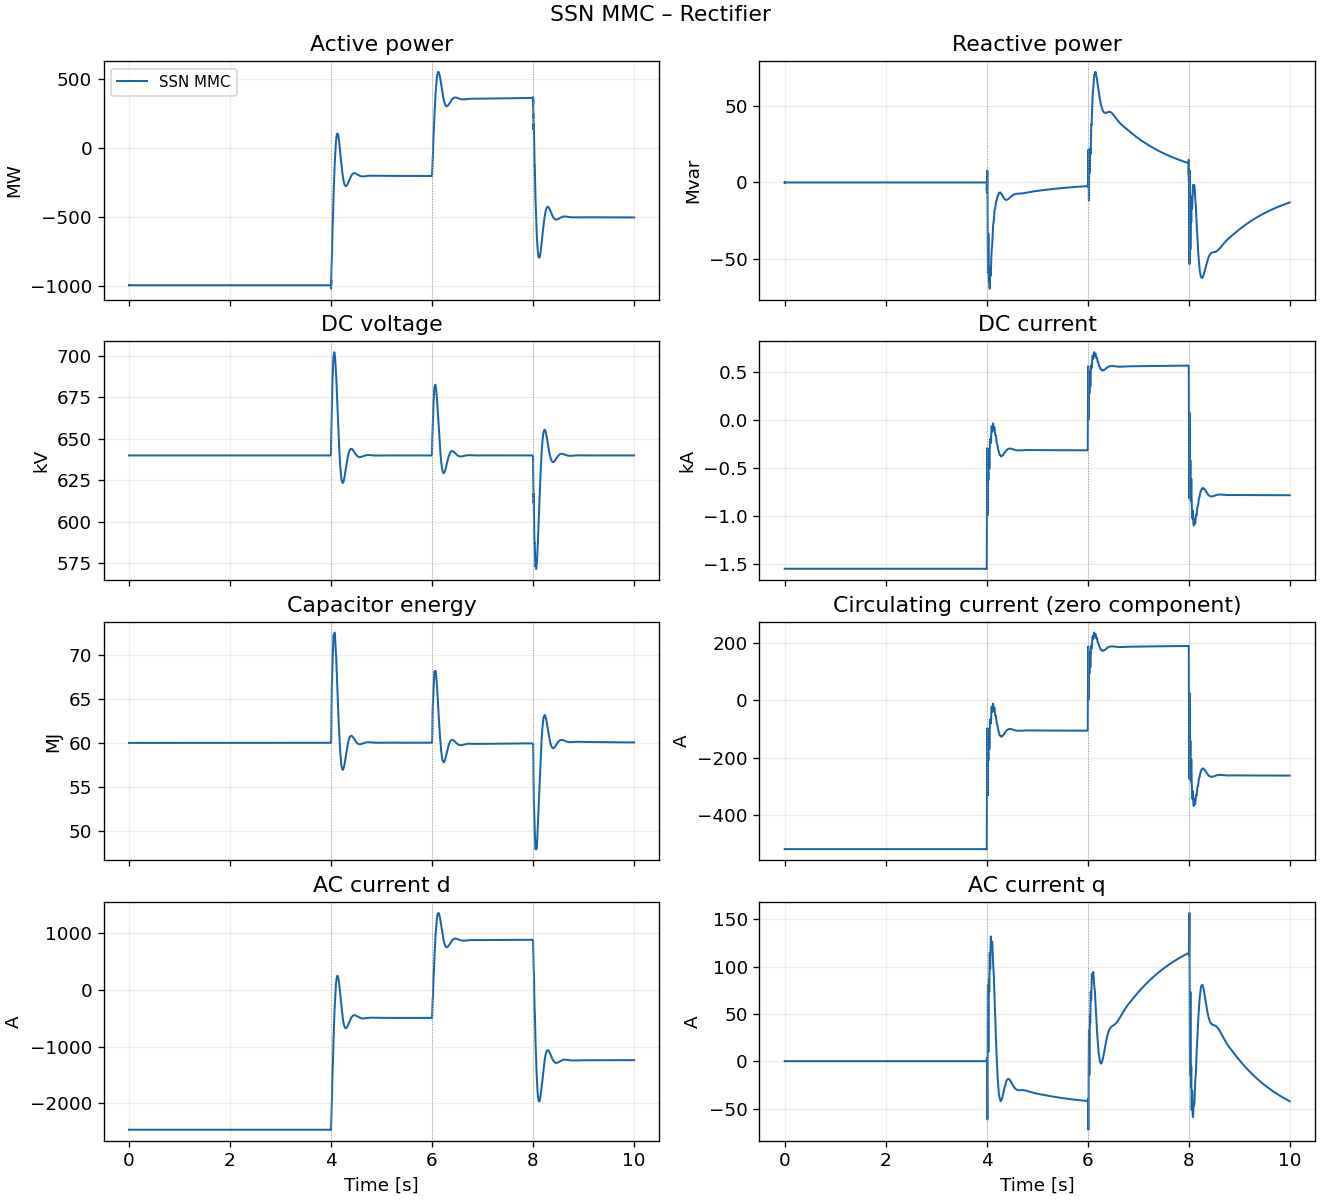

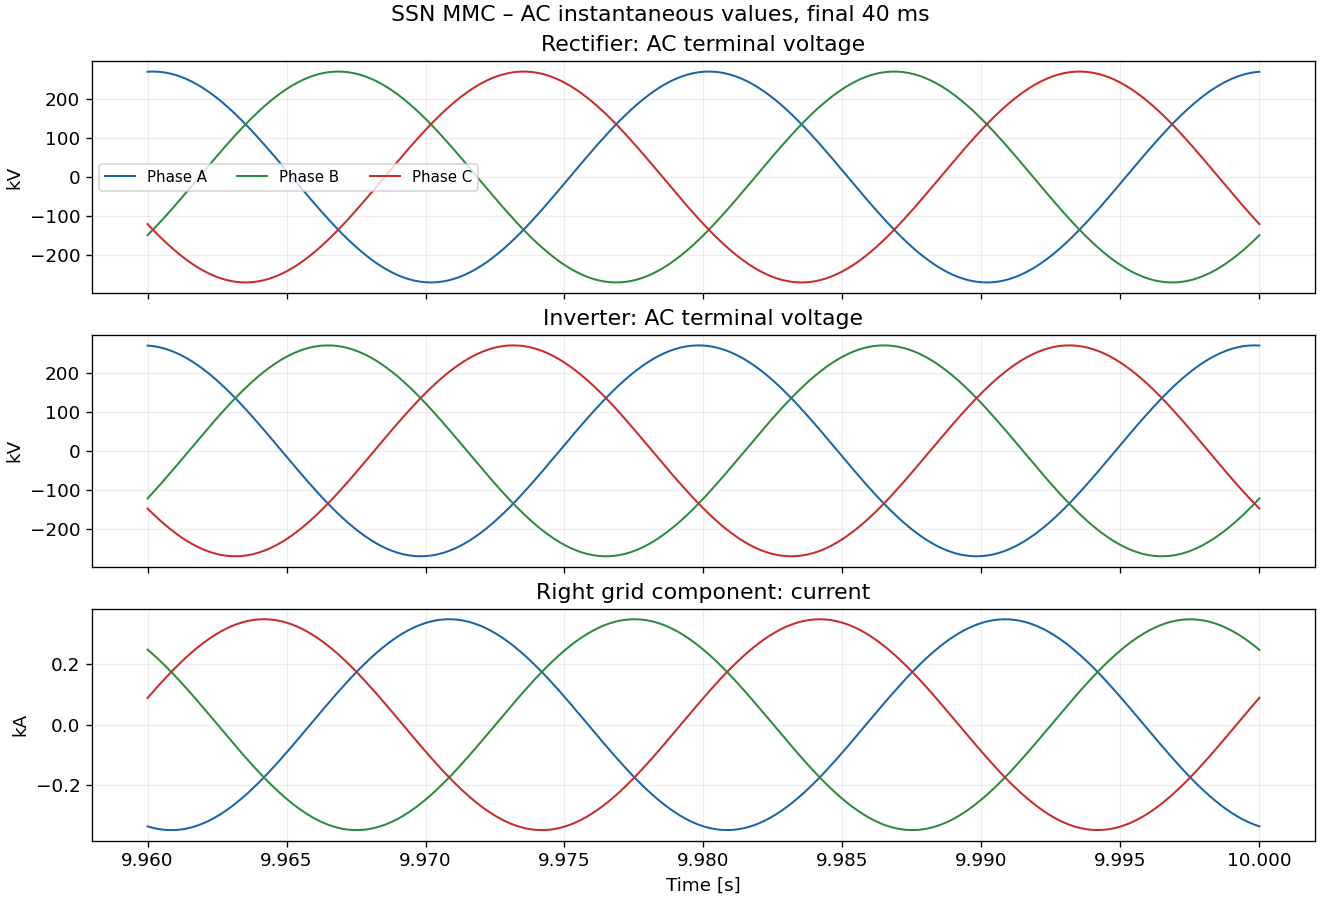

Individual plots saved as PNG and PDF: /home/ssc/HVDC/dpsim/outputs/mmc_mna/notebook_runs/20260928_103243_mmx4z6km/ssn_wwjbradl/plots


In [3]:
ssn_run = experiment.run_and_plot('ssn')


## 4. Run and plot the new MNA example

This cell runs **`EMT_MMC_MNA_Matlab_P2P_Results`** using the same settings. It displays the same three figures for the new MMC implementation.

Its measurements and run logs are saved in a separate directory from the SSN results.


MMC MNA is starting. Log: /home/ssc/HVDC/dpsim/outputs/mmc_mna/notebook_runs/20260928_103243_mmx4z6km/mna__it4guvt/run.log


MMC MNA: completed in 1 min 33.5 s.
CSV checked: 50,001 samples. Creating individual plots …


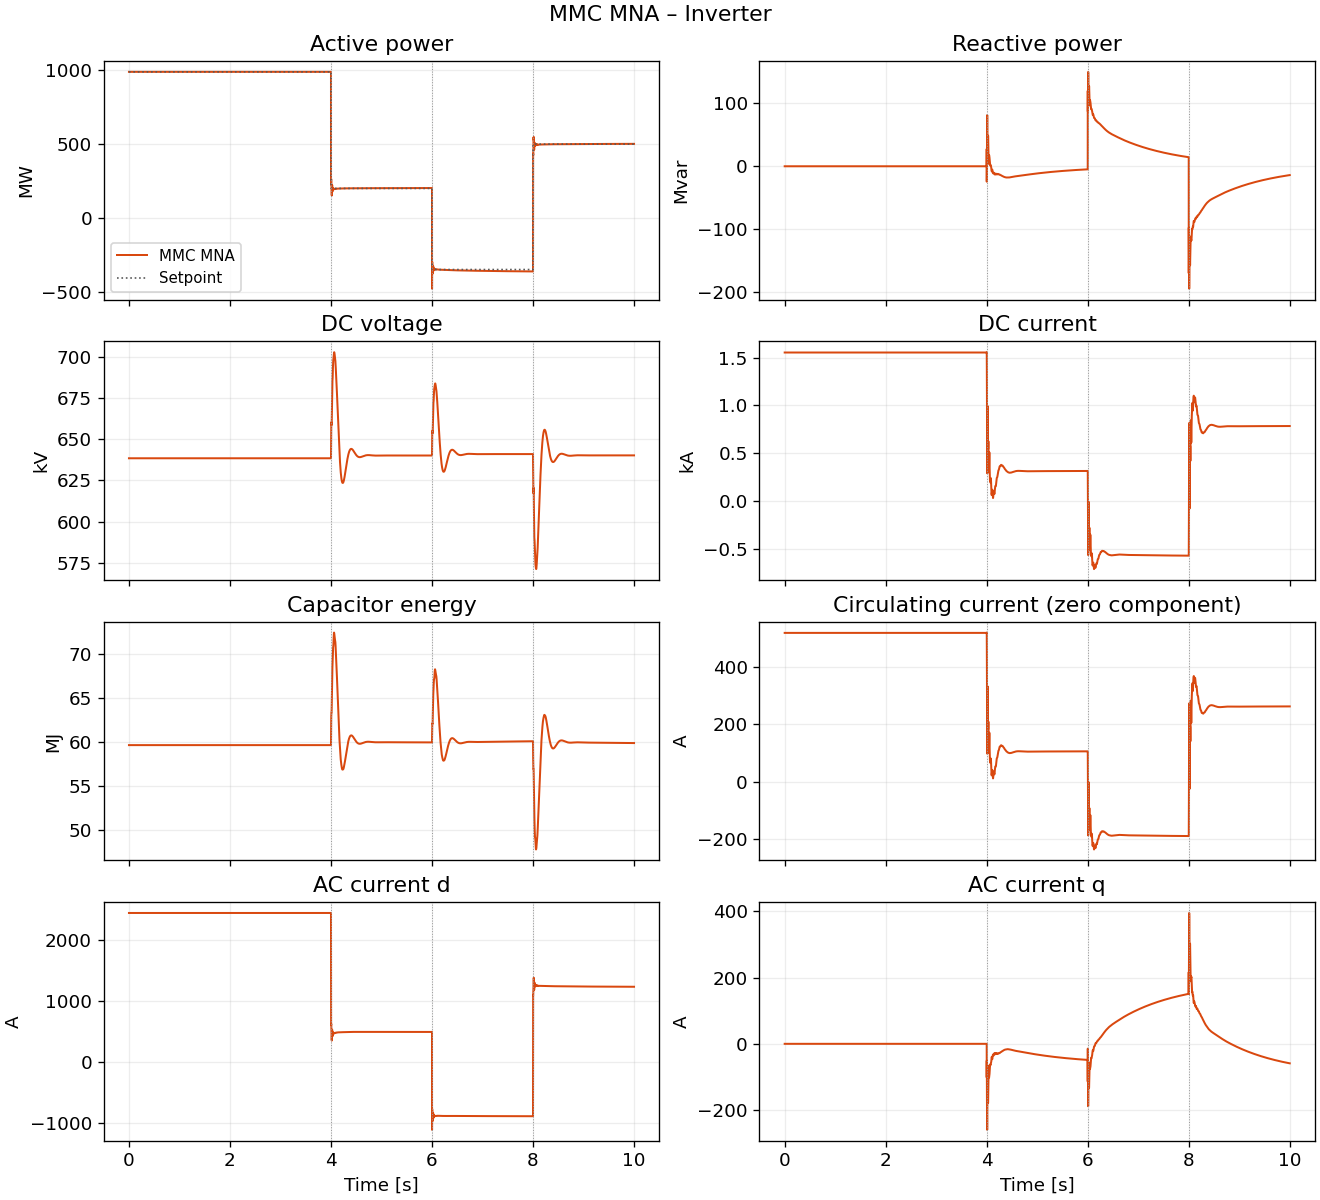

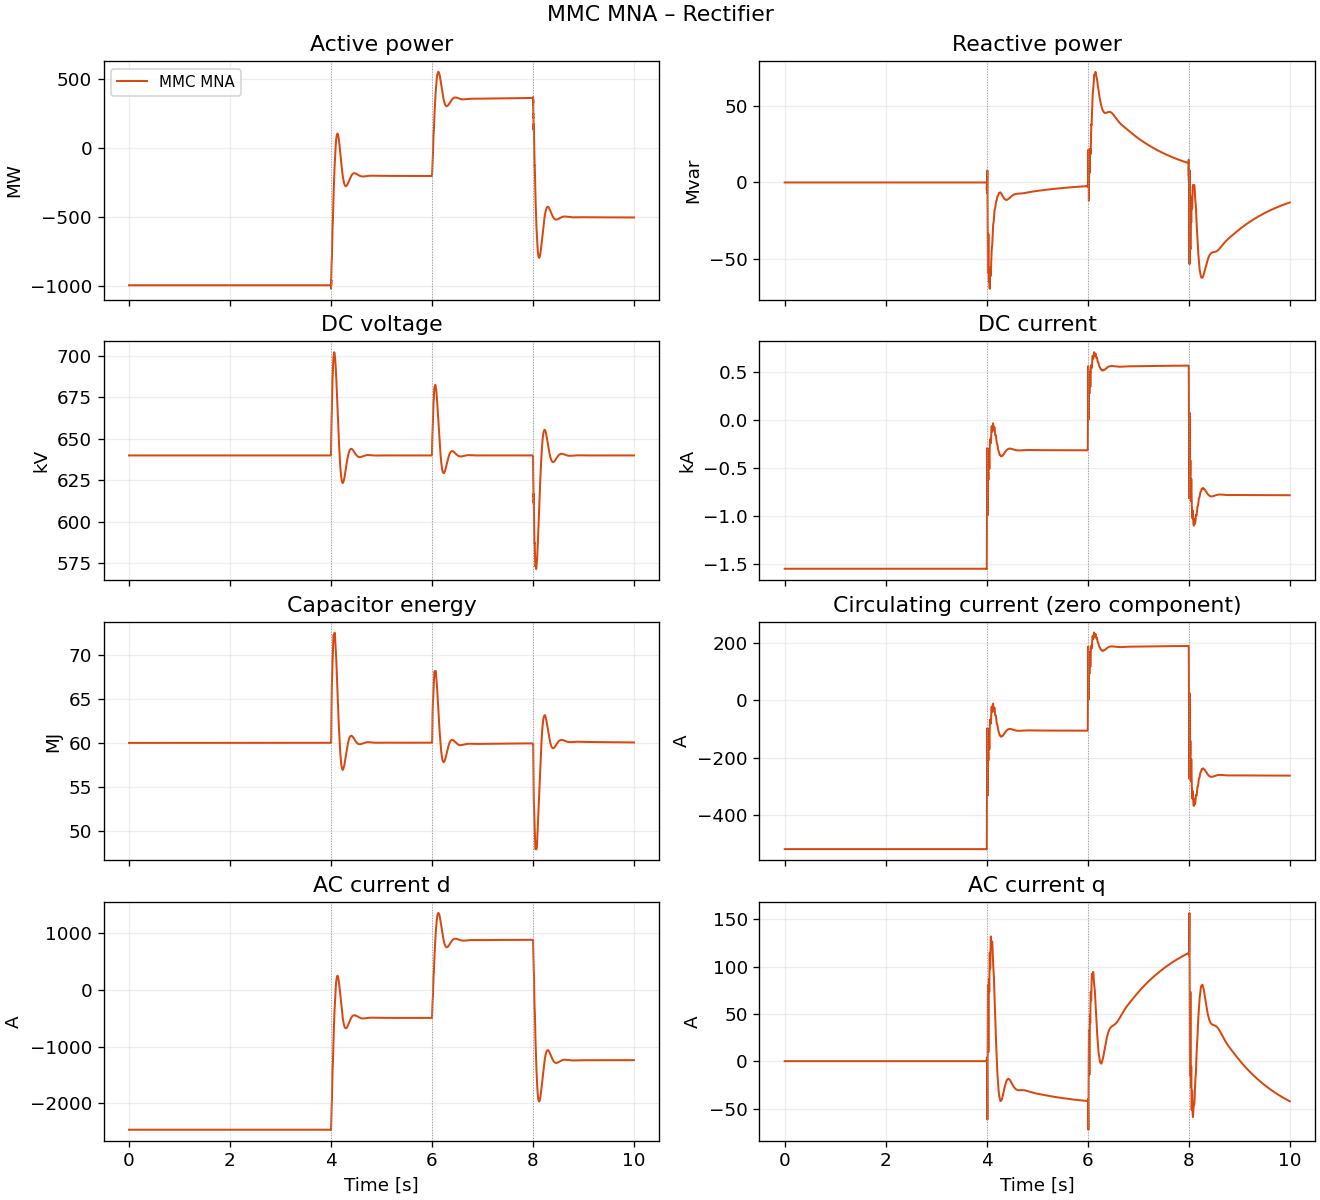

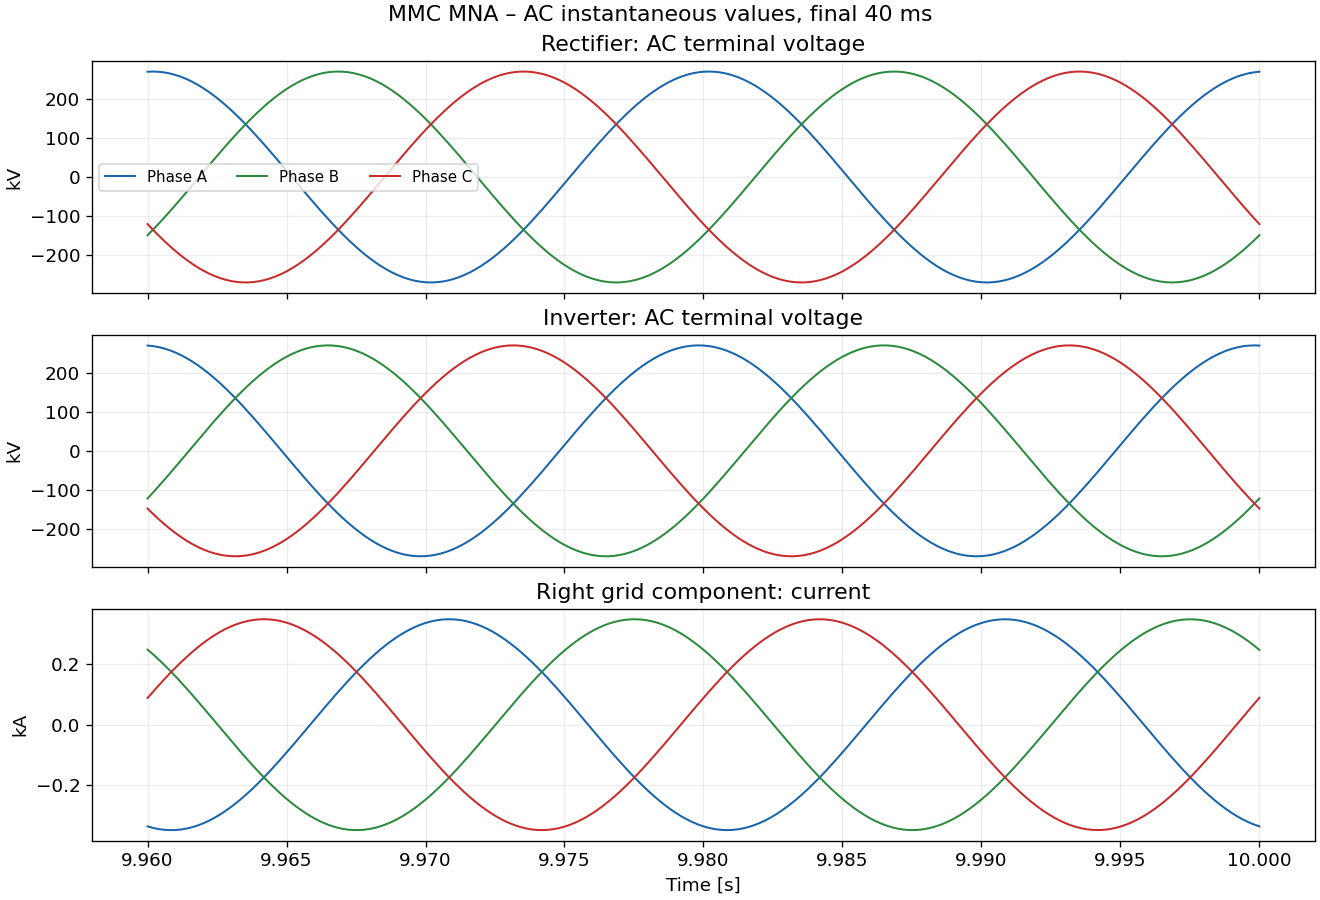

Individual plots saved as PNG and PDF: /home/ssc/HVDC/dpsim/outputs/mmc_mna/notebook_runs/20260928_103243_mmx4z6km/mna__it4guvt/plots


In [4]:
mna_run = experiment.run_and_plot('mna')


## 5. Compare SSN and MNA

This cell compares the two successful runs from the current experiment. It displays:

- Measured wall times and a table covering all 16 main signals.
- Overlaid curves: **blue = SSN**, **dashed orange = MNA** in the station overview and step plots.
- Differences, defined as **MNA minus SSN**. In the difference plots, colors identify the two stations.
- Close-ups of the steps at 4, 6, and 8 s, where covered by the simulation interval.
- Overlaid three-phase AC waveforms, with colors identifying phases and line styles identifying models.

**Maximum error** is the largest absolute difference at the saved sample times. **RMS error** measures the difference averaged over time using the square root of its mean square. Percentages use fixed engineering bases such as **1 GW**, **640 kV**, and **60 MJ**, rather than instantaneous values near zero. This compares the two models; it does not independently validate them against a physical installation.

As in the existing comparison script, CSV timestamps after the initial row are corrected for the known offset of one EMT step. This cell processes the completed runs without starting another electrical simulation.


Comparing SSN and MNA is starting. Log: /home/ssc/HVDC/dpsim/outputs/mmc_mna/notebook_runs/20260928_103243_mmx4z6km/comparison_n82fr06_/comparison.log


Comparing SSN and MNA: completed in 0 min 15.3 s.


| Run | Measured wall time |
|---|---:|
| SSN | 3 min 45.6 s |
| MNA | 1 min 33.5 s |

**Largest normalized error:** `inverter.q_ac` = **0.0736587 %**.

Percentages use fixed engineering bases (e.g. 1 GW and 640 kV), rather than each instantaneous value. The difference is always **MNA minus SSN**.

| Signal | Maximum error | RMS error | Maximum / base |
|---|---:|---:|---:|
| rectifier.p_ac | 0.618977 MW | 0.00728638 MW | 0.0618977 % |
| rectifier.q_ac | 0.267155 Mvar | 0.00454863 Mvar | 0.0267155 % |
| rectifier.vdc | 0.0254703 kV | 0.000420794 kV | 0.00397973 % |
| rectifier.idc | 2.7154e-05 kA | 1.07061e-05 kA | 0.00173786 % |
| rectifier.energy | 9.58056e-05 MJ | 1.57554e-05 MJ | 0.000159676 % |
| rectifier.i_sigma_z | 0.009051 A | 0.00356855 A | 0.00173779 % |
| rectifier.i_delta_d | 0.016006 A | 0.00234348 A | 0.000652789 % |
| rectifier.i_delta_q | 0.008082 A | 0.00342793 A | 0.000329616 % |
| inverter.p_ac | 0.314808 MW | 0.00344355 MW | 0.0314808 % |
| inverter.q_ac | 0.736587 Mvar | 0.00558042 Mvar | 0.0736587 % |
| inverter.vdc | 0.0153966 kV | 0.000857998 kV | 0.00240572 % |
| inverter.idc | 2.7152e-05 kA | 1.07048e-05 kA | 0.00173773 % |
| inverter.energy | 0.000103226 MJ | 1.59993e-05 MJ | 0.000172044 % |
| inverter.i_sigma_z | 0.00905 A | 0.00356811 A | 0.0017376 % |
| inverter.i_delta_d | 0.0383 A | 0.00135356 A | 0.00156203 % |
| inverter.i_delta_q | 0.034708 A | 0.00414121 A | 0.00141553 % |

### Inverter: SSN and MNA overlaid

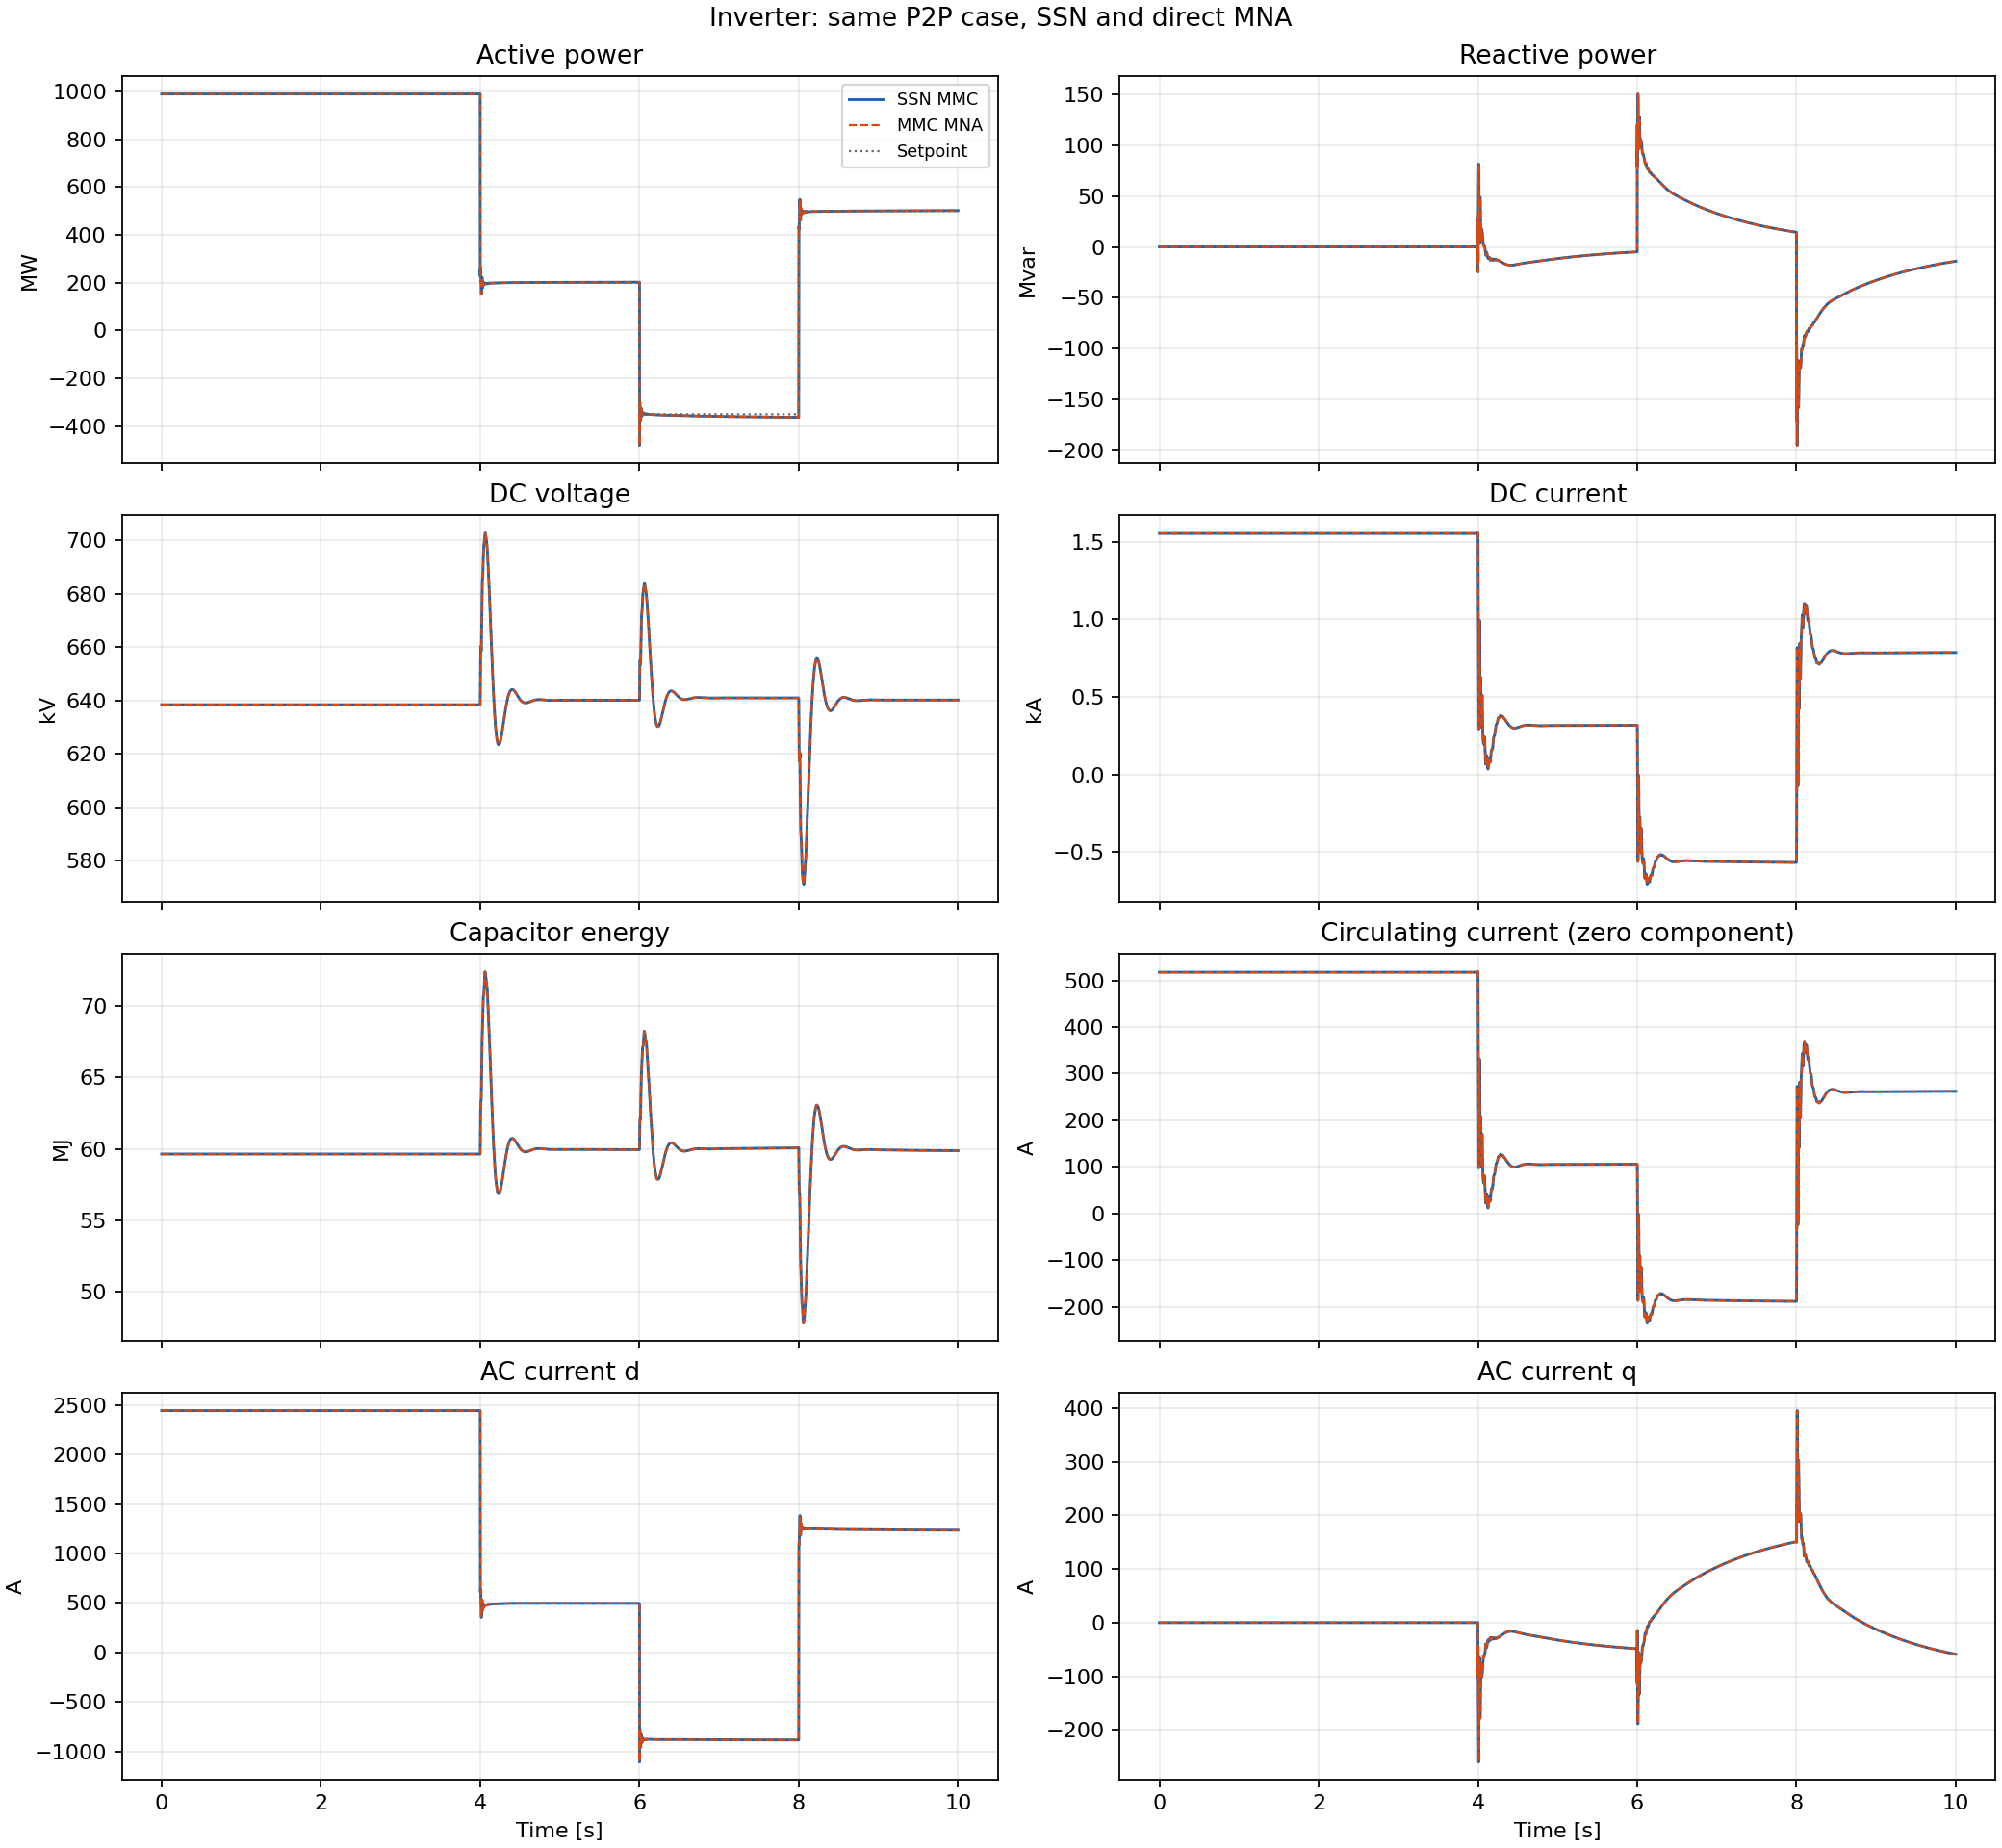

### Rectifier: SSN and MNA overlaid

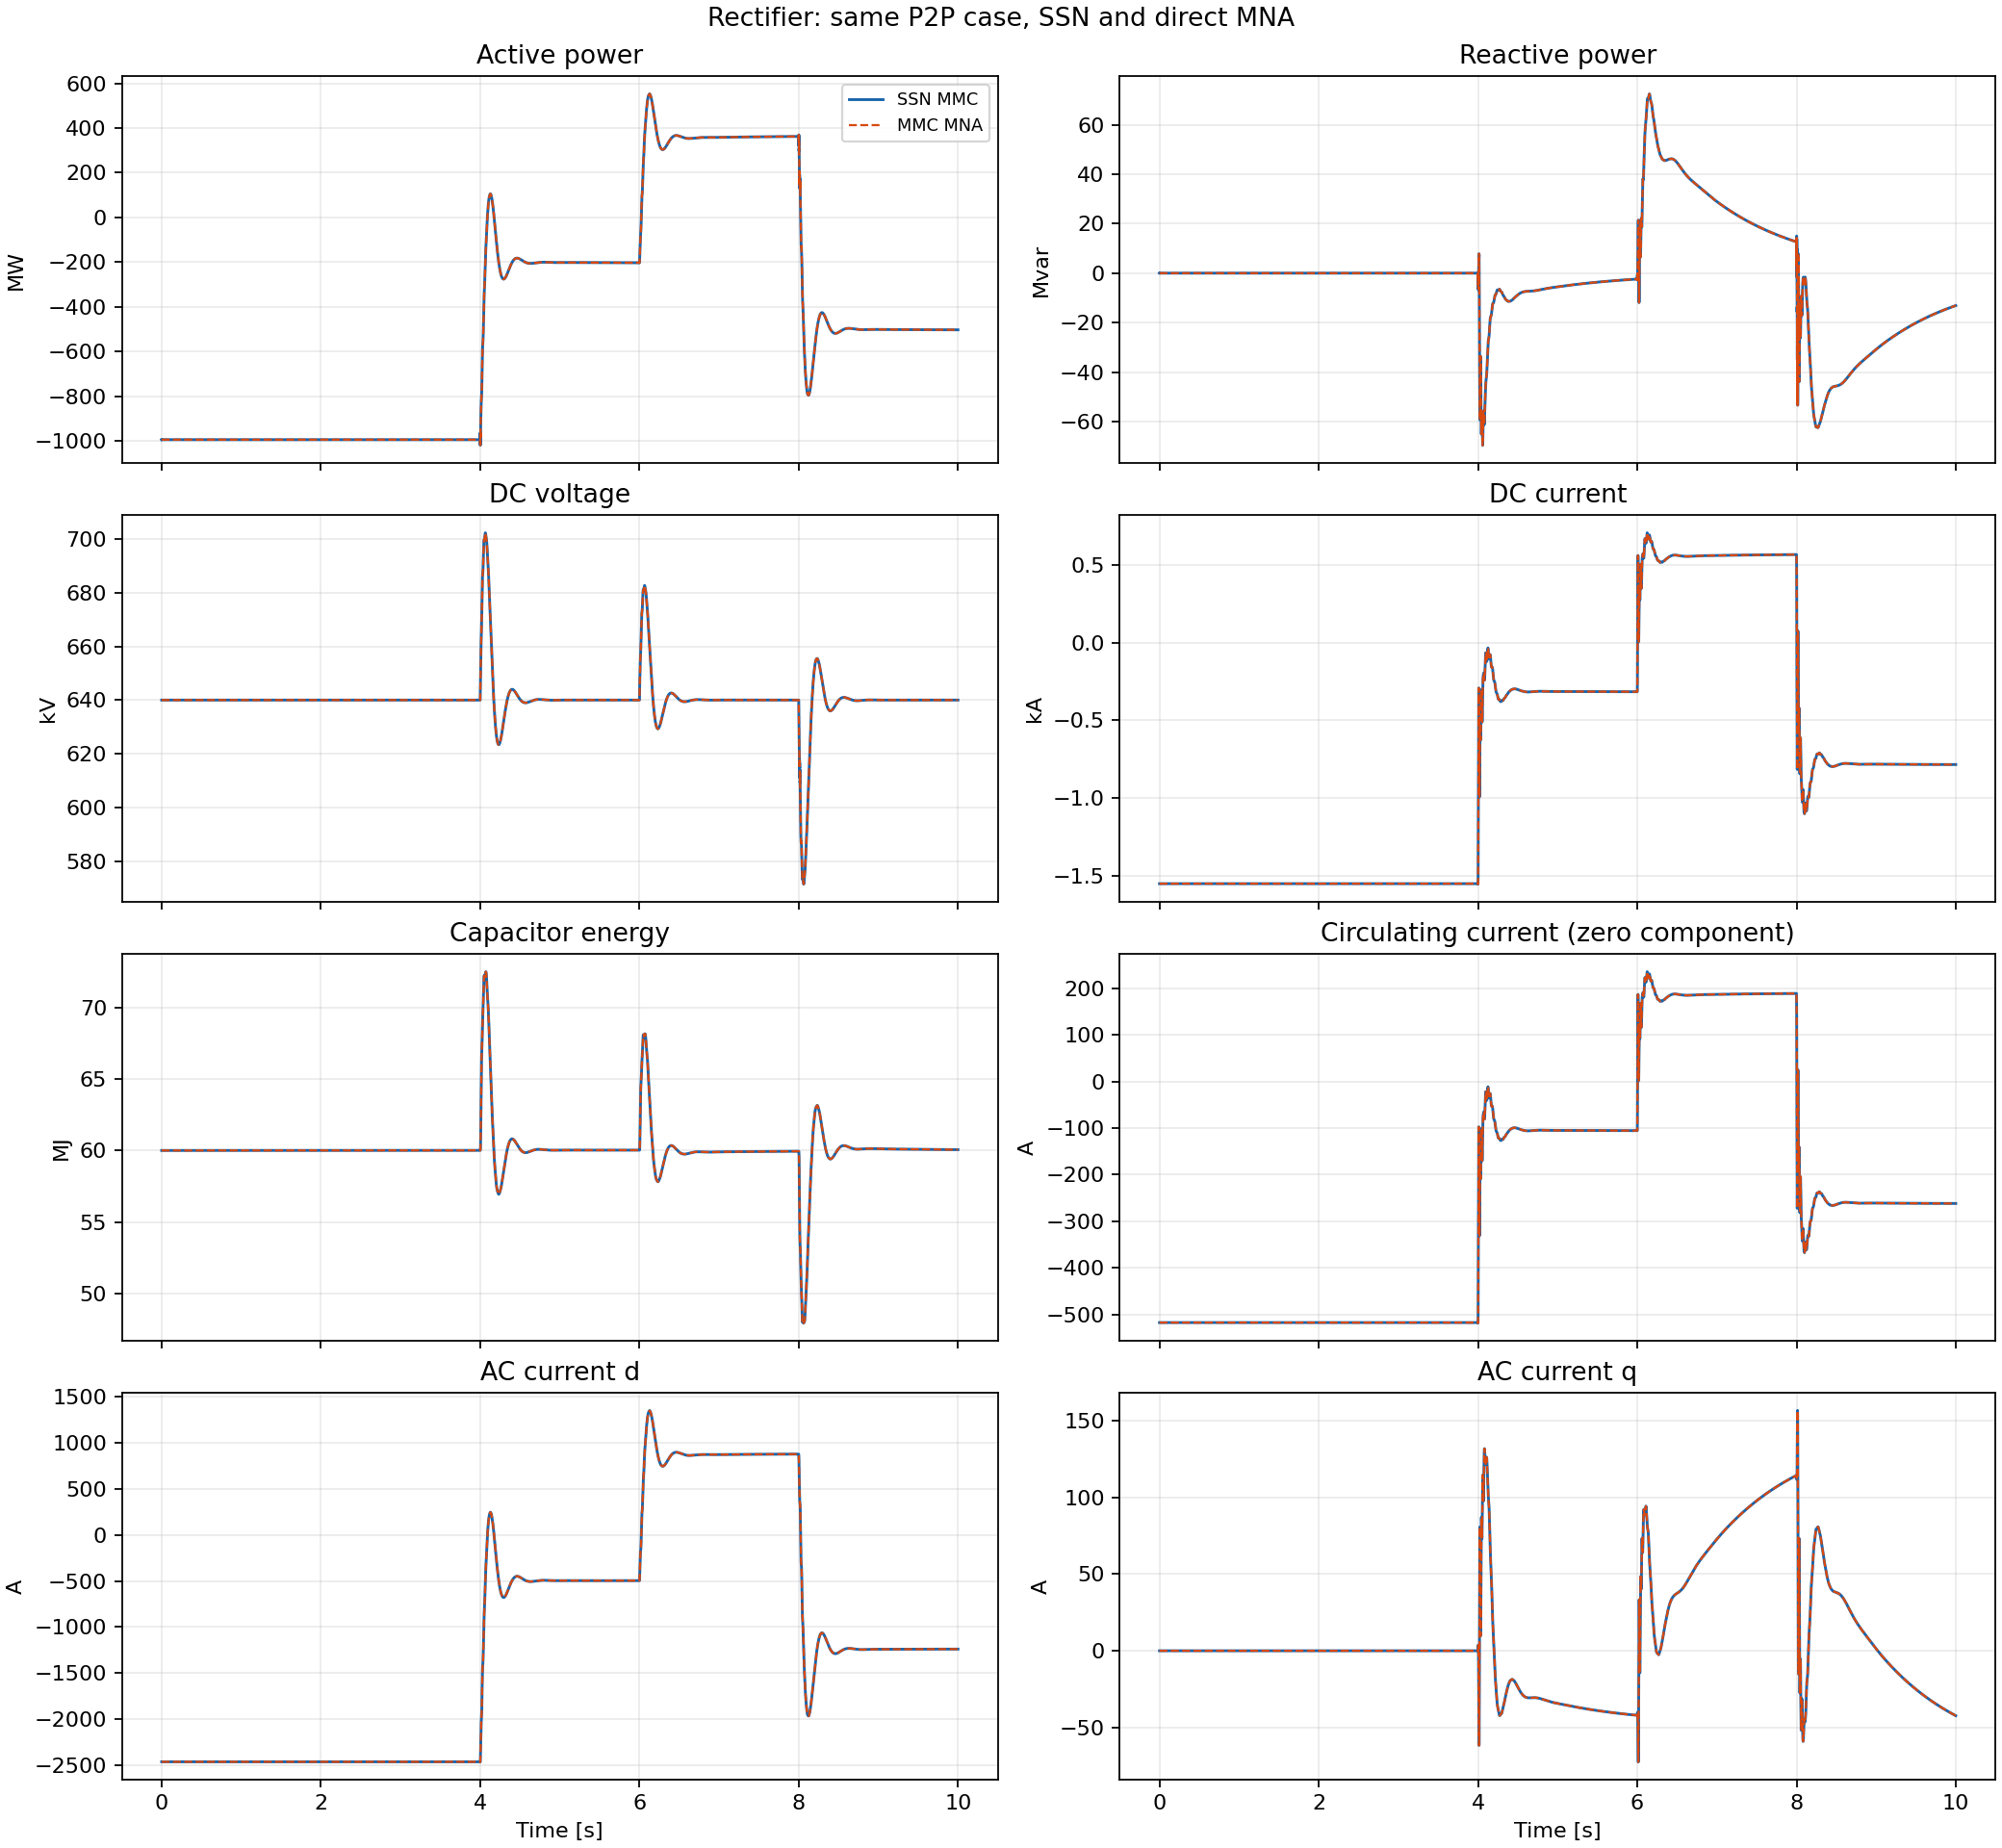

### Differences: MNA minus SSN

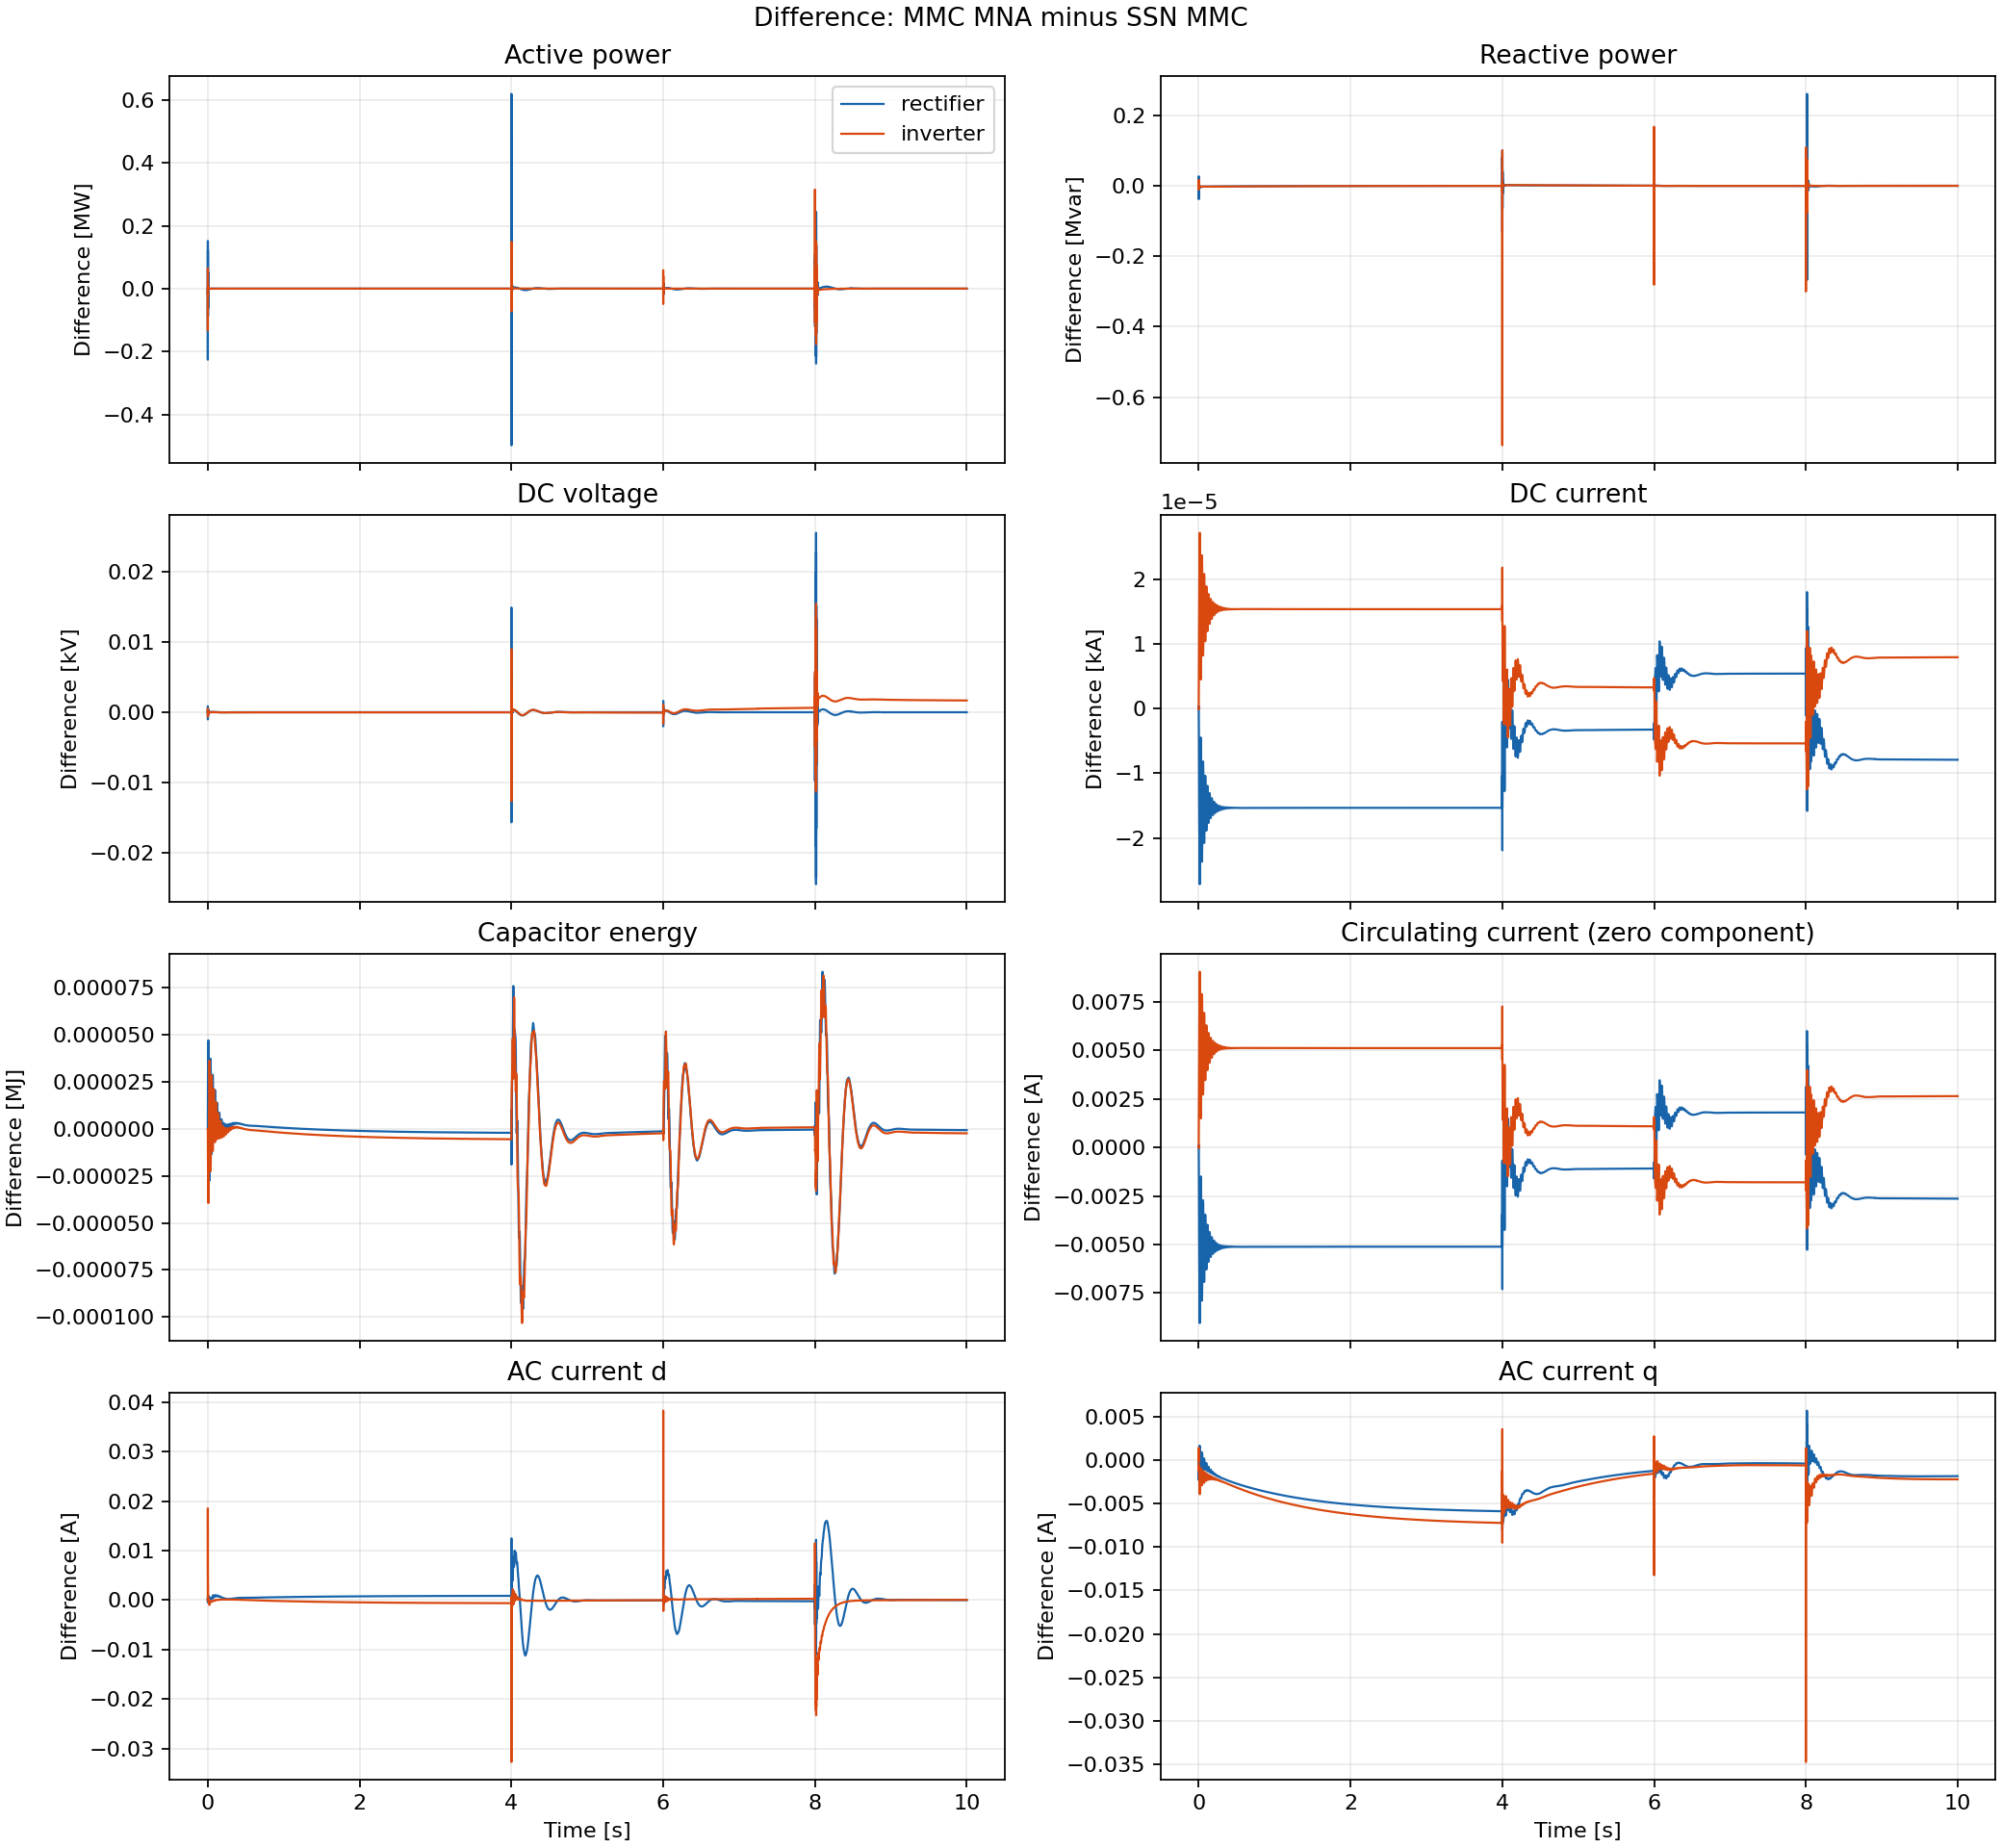

### Setpoint step at 4 s

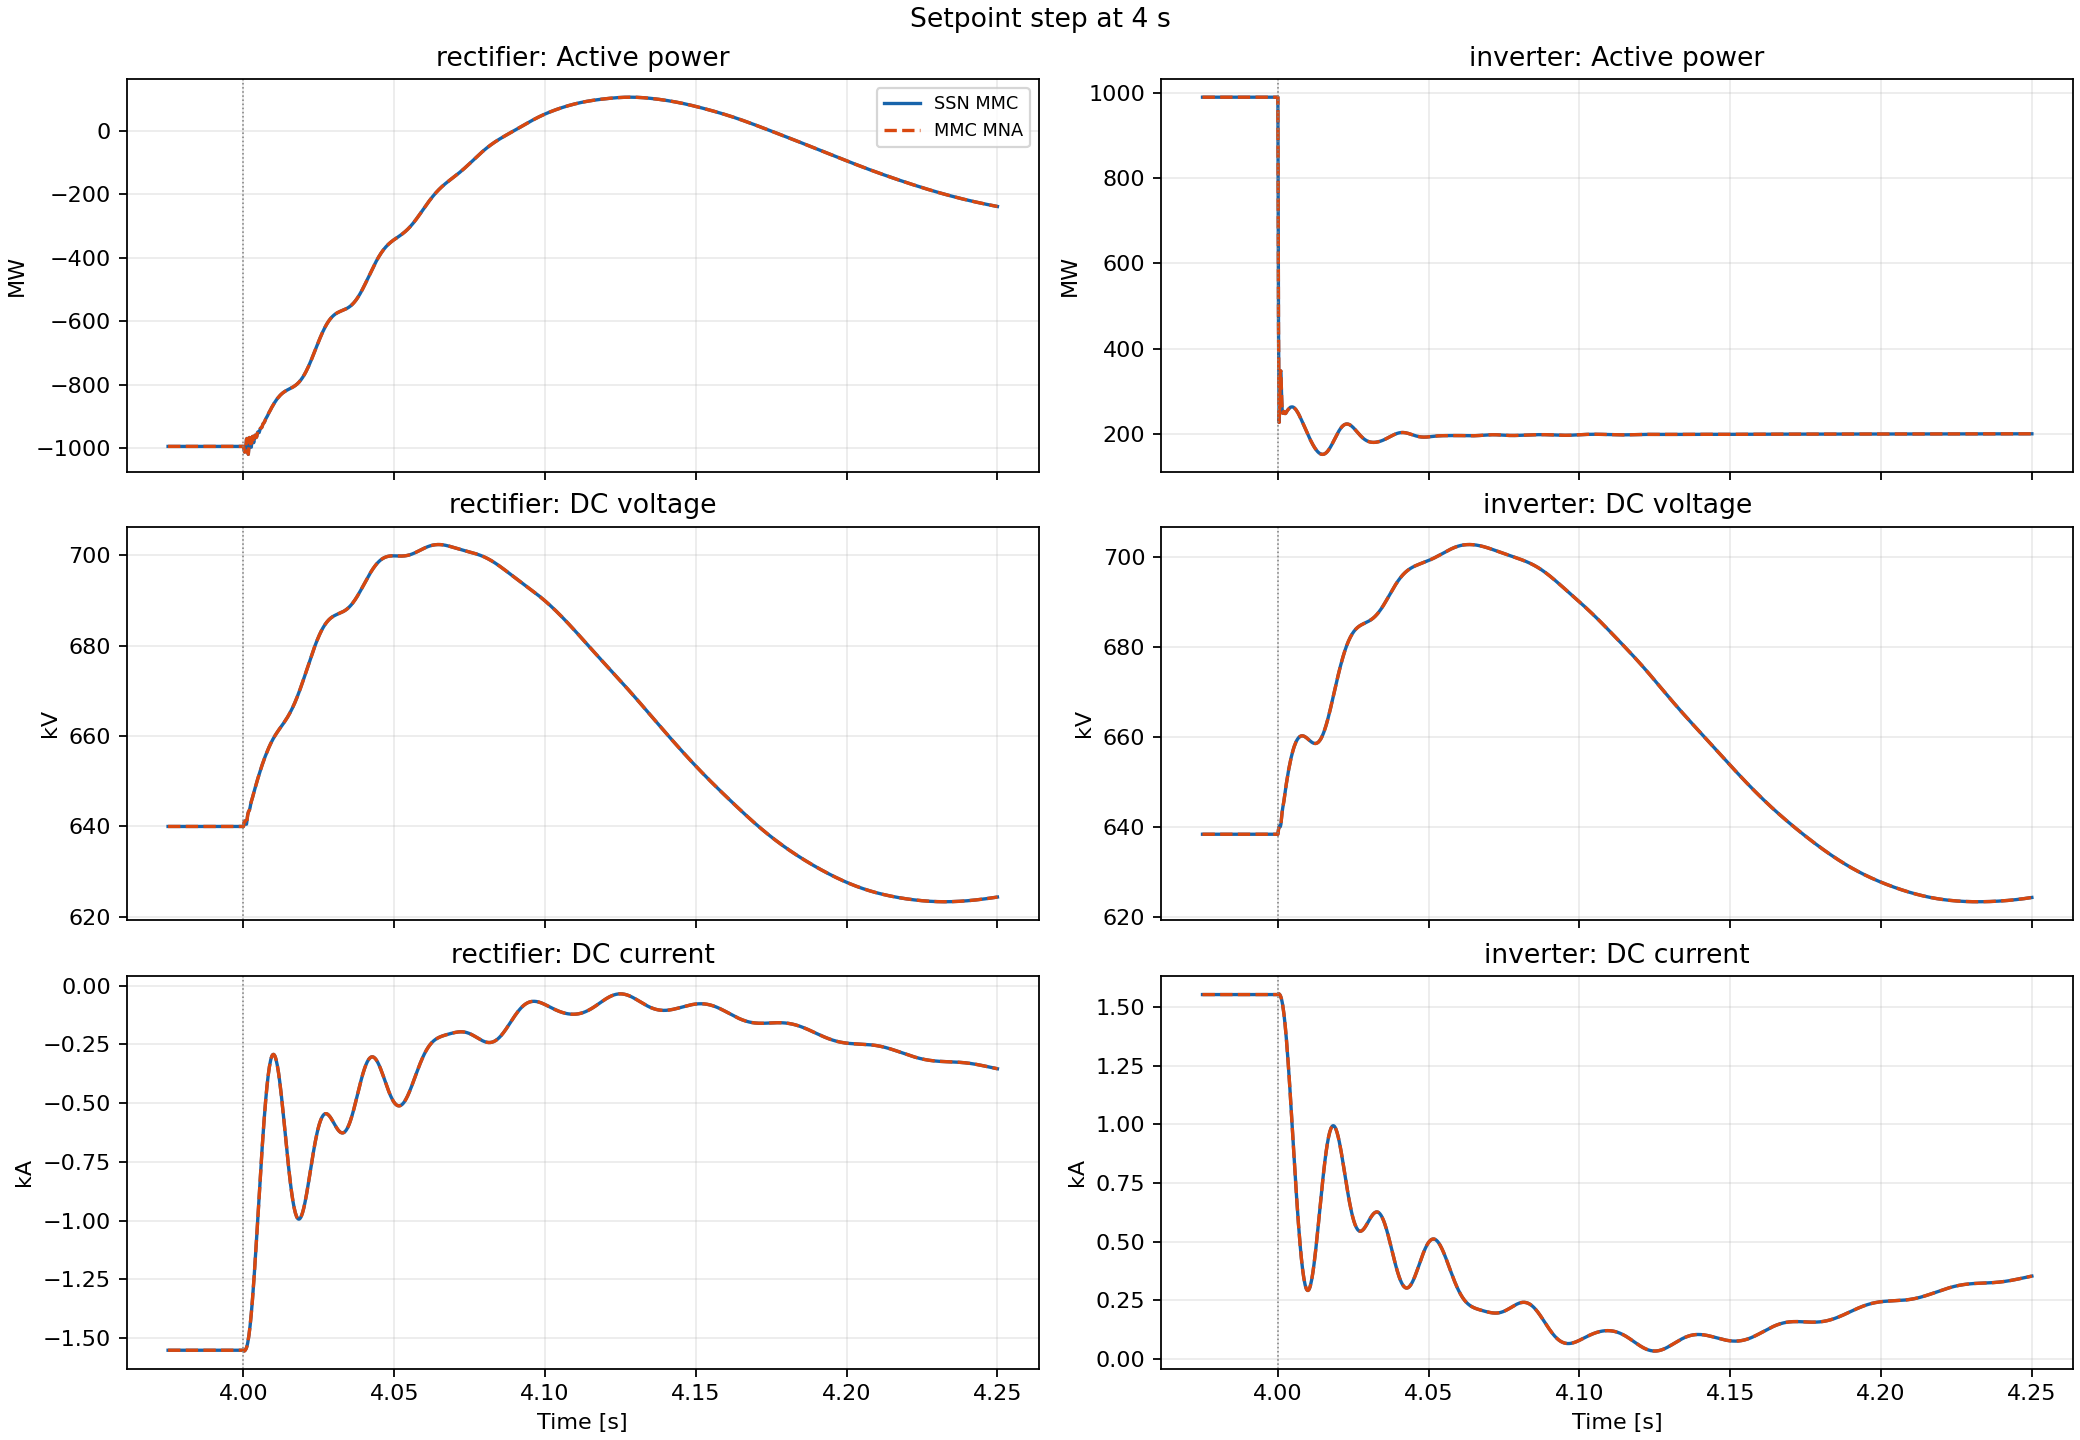

### Setpoint step at 6 s

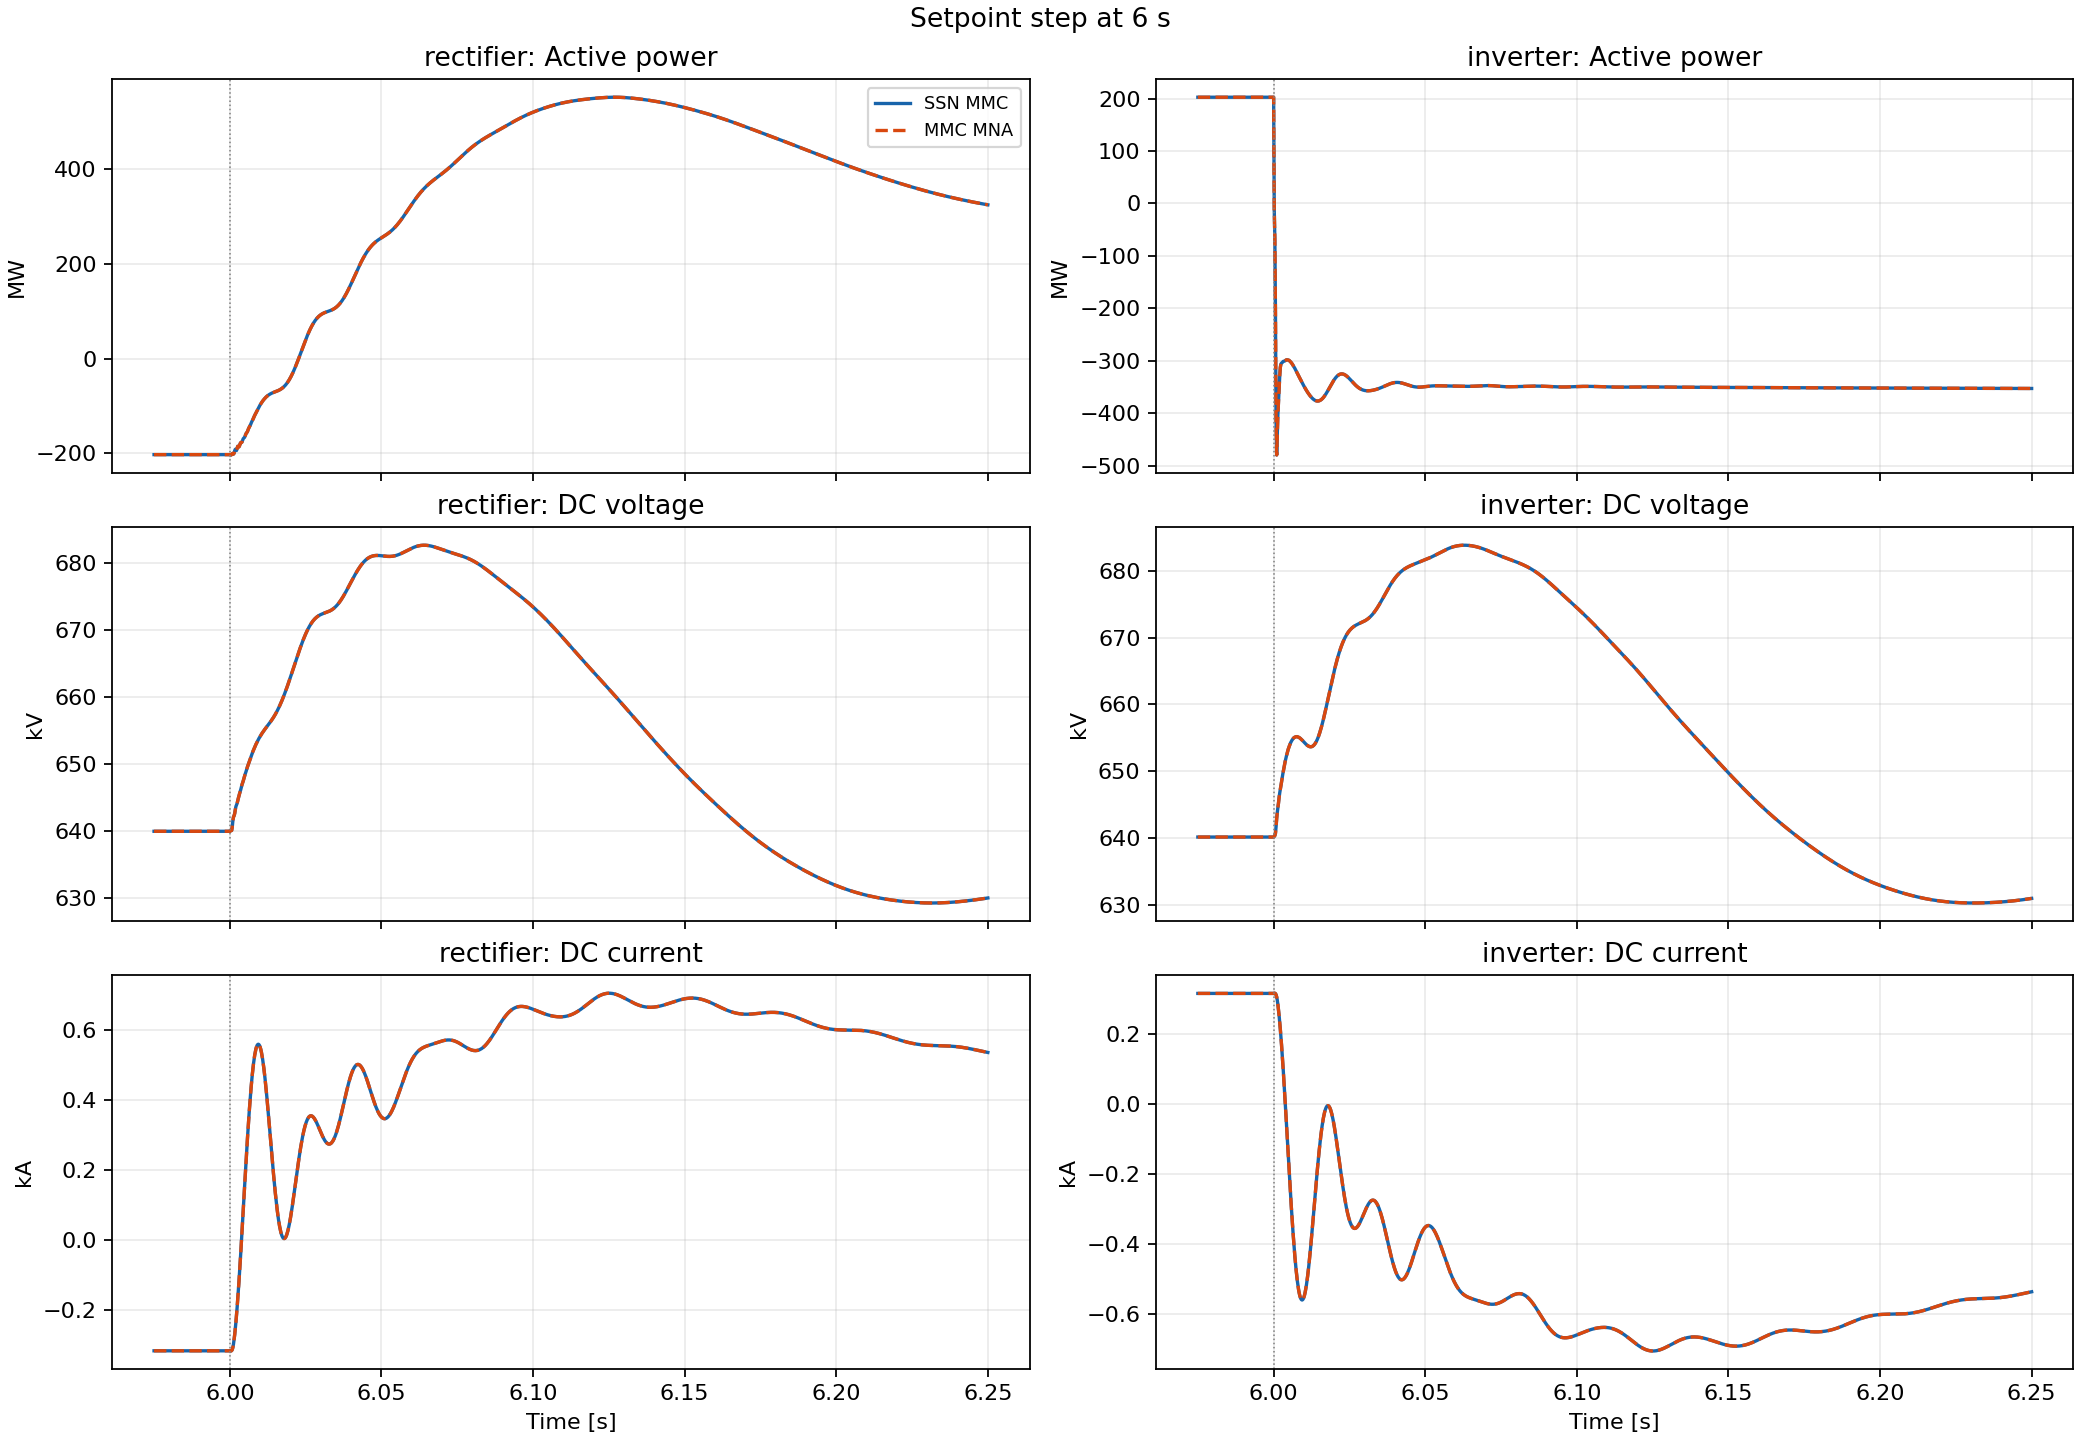

### Setpoint step at 8 s

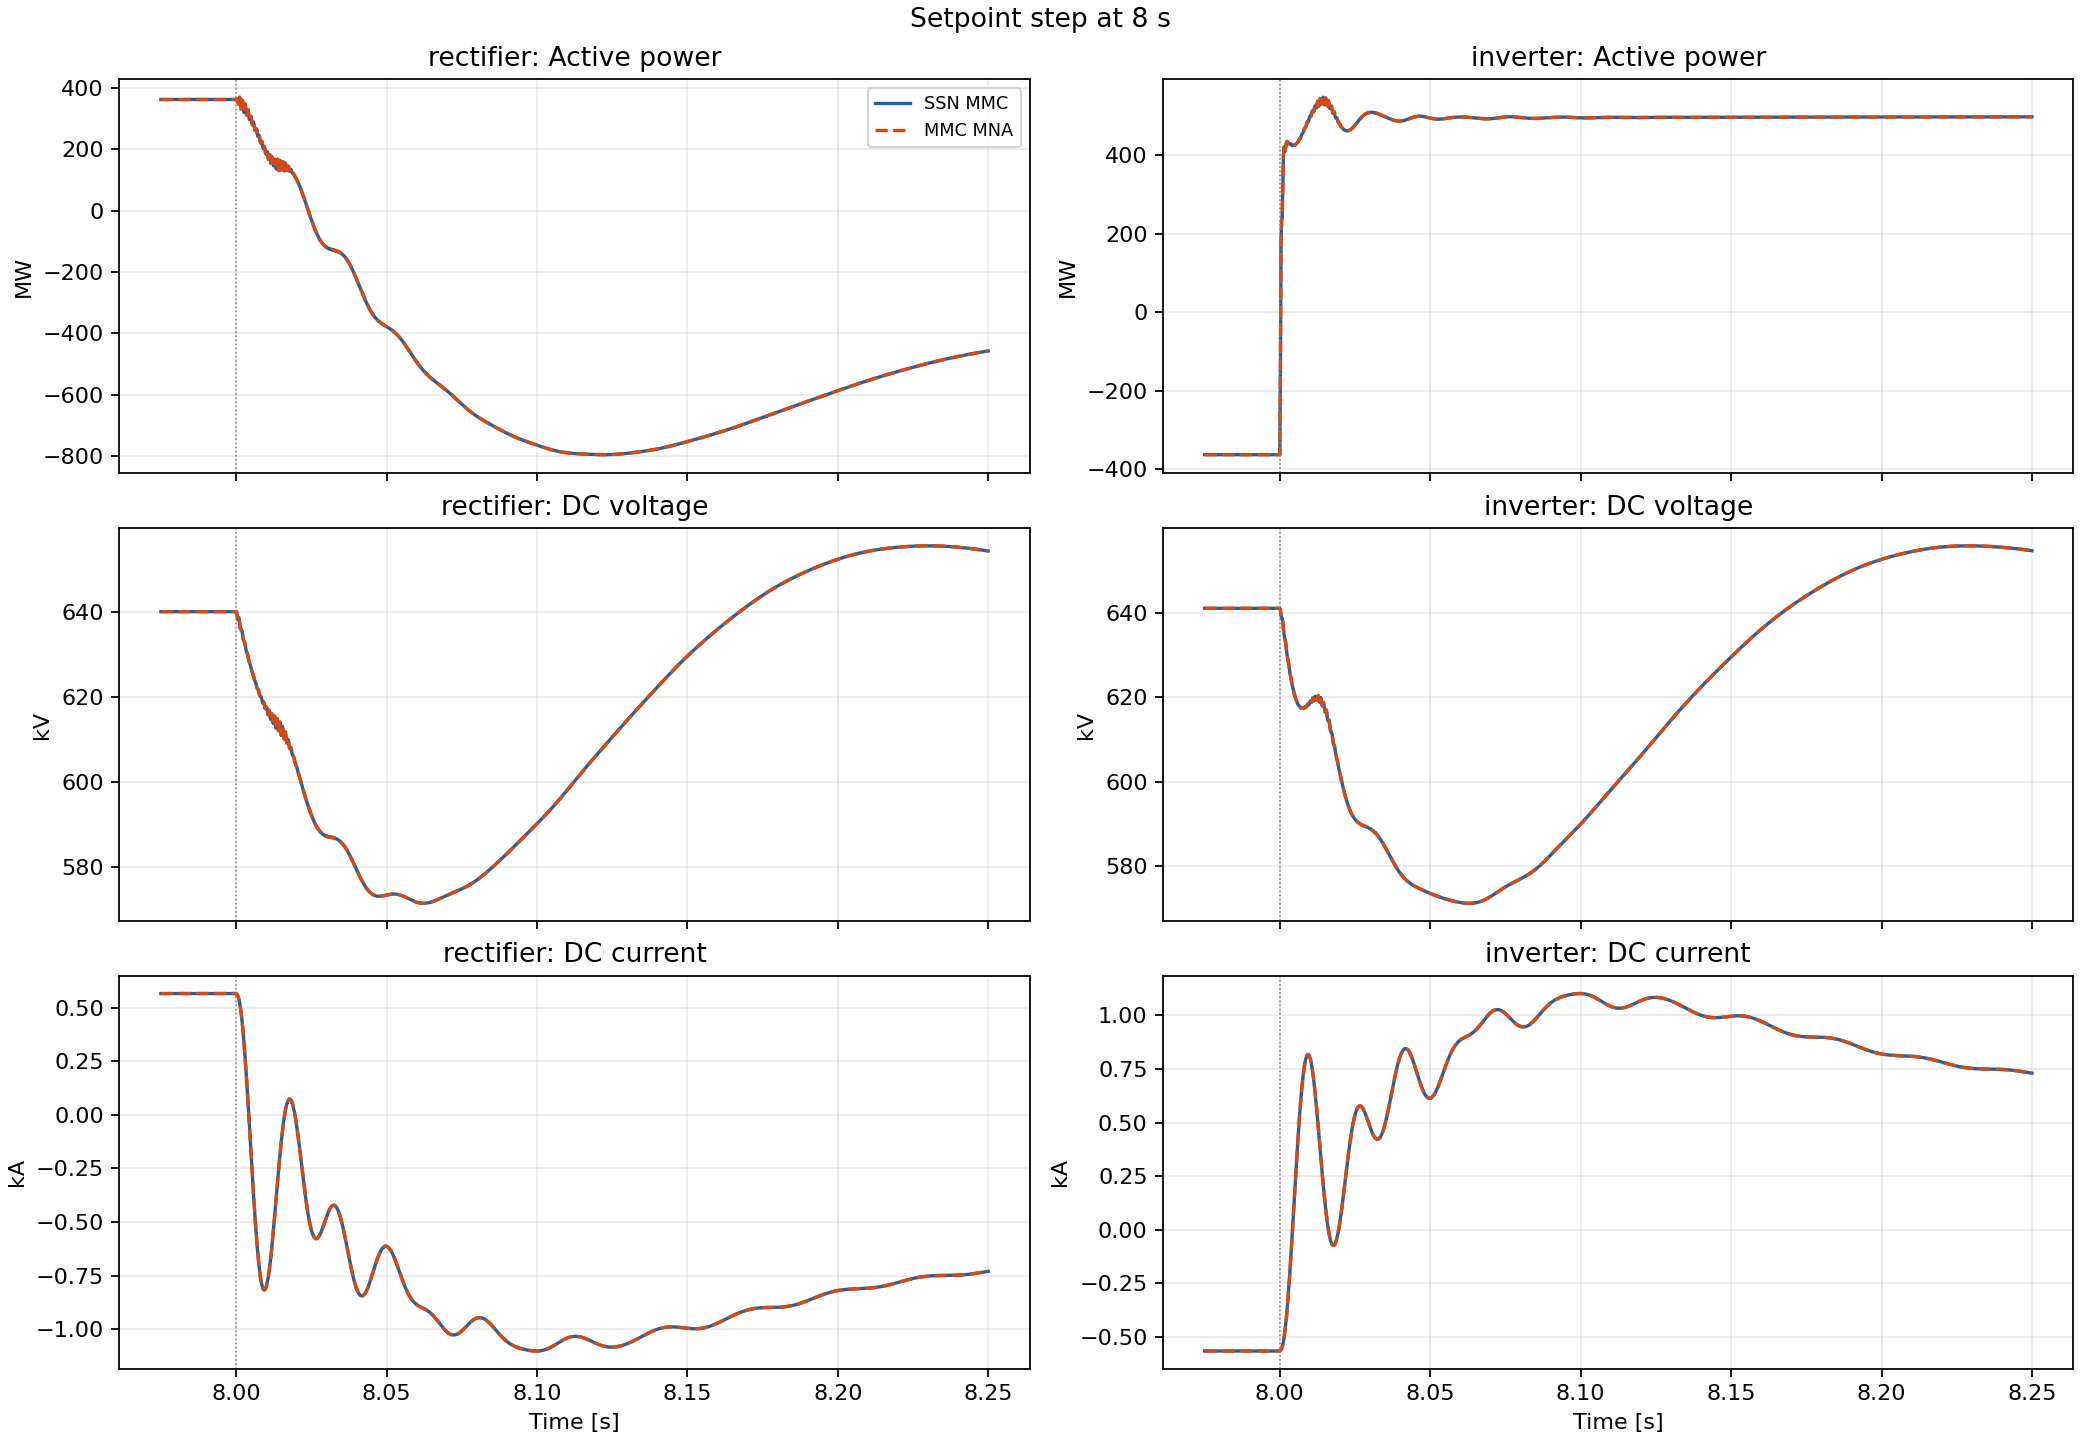

### Three-phase AC waveforms

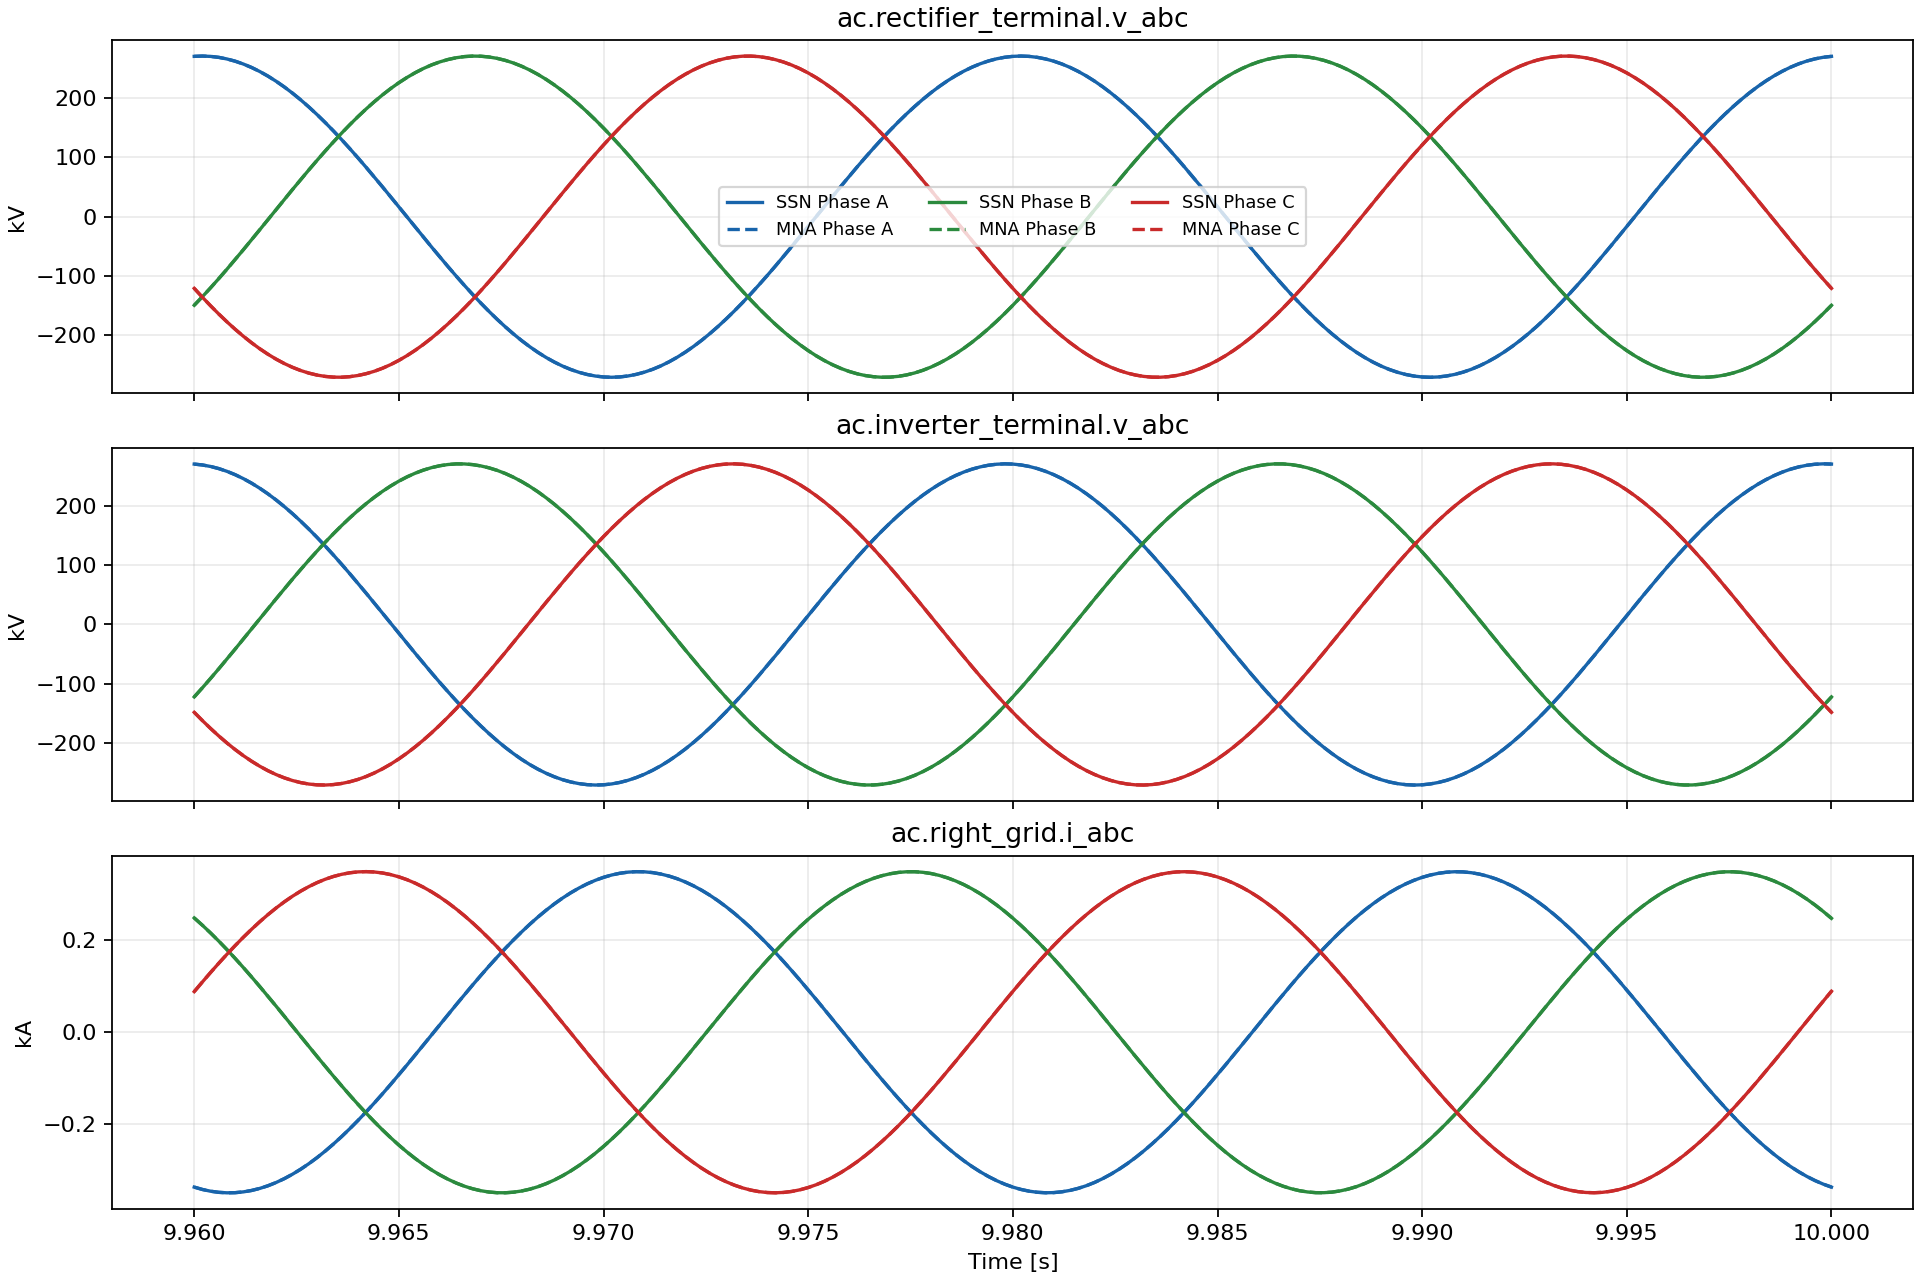

Comparison complete. PNG, PDF, report.md, and metrics: /home/ssc/HVDC/dpsim/outputs/mmc_mna/notebook_runs/20260928_103243_mmx4z6km/comparison_n82fr06_


In [5]:
comparison = experiment.compare()


## Results, repeating runs, and stopping

The settings cell prints the exact output directory. Each run contains **`run.log`**, **`run.json`**, the CSV under **`logs/`**, and individual figures under **`plots/`**. The comparison has its own directory containing **`report.md`**, **`metrics.csv`**, **`metrics.json`**, and PNG/PDF figures. Existing results in `reference_20us` and `reference_10us` remain available.

- **Change the time step:** edit and execute the settings cell, then run both simulation cells and the comparison again.
- **Repeat one run:** execute its cell again. It writes to a new subdirectory. The next comparison uses the most recent successful run from each model; a failed or interrupted replacement must be rerun successfully first.
- **Display plots again:** execute `experiment.plot_run('ssn')` or `experiment.plot_run('mna')` in an additional cell. This reuses the saved data.
- **Stop a run:** use the kernel's Stop/Interrupt button. The helper also terminates the simulation process. An interrupted run cannot be compared.
- **Restart the kernel:** start again from the top. Existing files remain on disk, but Python variables must be recreated.
- **Handle an error:** read the final error message and its log path first. For missing Python packages, select **Python (DPsim)**.

For model details and command-line instructions, see [EMT_MMC_MNA_Comparison.md](EMT_MMC_MNA_Comparison.md).
